### **Quiz_04: ARIMA/SARIMA Forecasting using Apple Stock Prices**


**Student Names:**  
1. Awais Manzoor (SP24-BBD-026)  
2. Fawad Saqib (SP24-BBD-047)  
3. Umama Khalid (SP24-BBD-145)  
4. Nadia Shabir (SP24-BBD-113)  
5. M. Suleman (SP24-BBD-105) 
6. Abuzar     (SP24-BBD-004)
7. Bilal      (SP24-BBD-035)

**Instructor Name:** Sir Qamar Abbas 

#### **Objective:**
To apply ARIMA/SARIMA time series forecasting techniques on Apple (AAPL) stock price data, validate forecasting models, generate short-term forecasts, and provide investor-oriented business insights.

### **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.stats.diagnostic import acorr_ljungbox

import warnings
warnings.filterwarnings('ignore')

### **Load Dataset**

In [2]:
df = pd.read_csv("aapl.csv")
df.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,2008-10-14,116.26,116.40,103.14,104.08,70749800,104.08
1,2008-10-13,104.55,110.53,101.02,110.26,54967000,110.26
2,2008-10-10,85.70,100.00,85.00,96.80,79260700,96.80
3,2008-10-09,93.35,95.80,86.60,88.74,57763700,88.74
4,2008-10-08,85.91,96.33,85.68,89.79,78847900,89.79


### **Data Preparation**

In [3]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as index
df.set_index('Date', inplace=True)

# Select Close price
ts = df['Close']

# Sort index
ts = ts.sort_index()

ts.head()

Date
1984-09-07    26.50
1984-09-10    26.37
1984-09-11    26.87
1984-09-12    26.12
1984-09-13    27.50
Name: Close, dtype: float64

## **Plot Original Time Series**

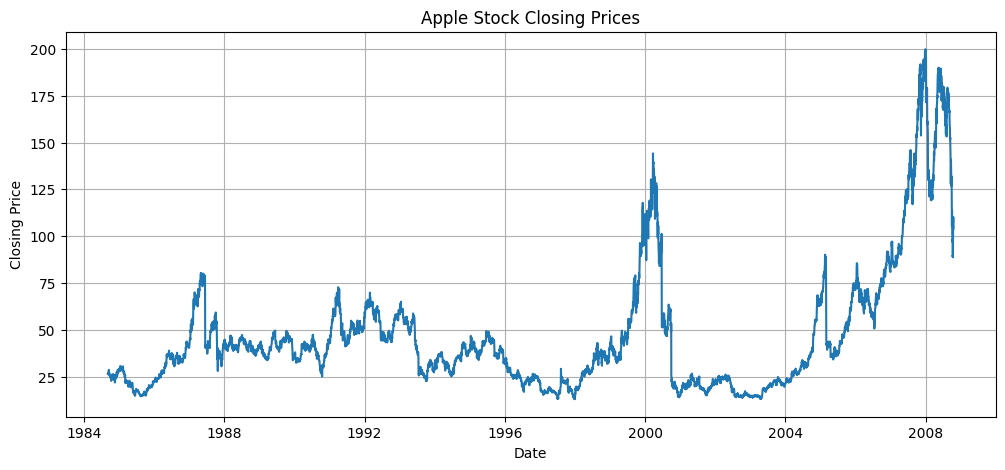

In [4]:
plt.figure(figsize=(12,5))
plt.plot(ts)

plt.title("Apple Stock Closing Prices")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.grid(True)
plt.show()

- The stock prices show fluctuations and trend behavior over time, indicating possible time dependency.

### **ADF Test for Stationarity**

In [5]:
def adf_test(series, name):

    result = adfuller(series)

    print(f"ADF Test for {name}")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("\nCritical Values:")

    for key, value in result[4].items():
        print(key, ":", value)

    if result[1] < 0.05:
        print("\nConclusion: Series is Stationary")

    else:
        print("\nConclusion: Series is Non-Stationary")


adf_test(ts, "Original Series")

ADF Test for Original Series
ADF Statistic: -2.585882489849596
p-value: 0.09595031519416458

Critical Values:
1% : -3.431431513832865
5% : -2.862017930409106
10% : -2.5670243997973676

Conclusion: Series is Non-Stationary


- The ADF test shows the stock price series is  non-stationary.

### **First Order Differencing**

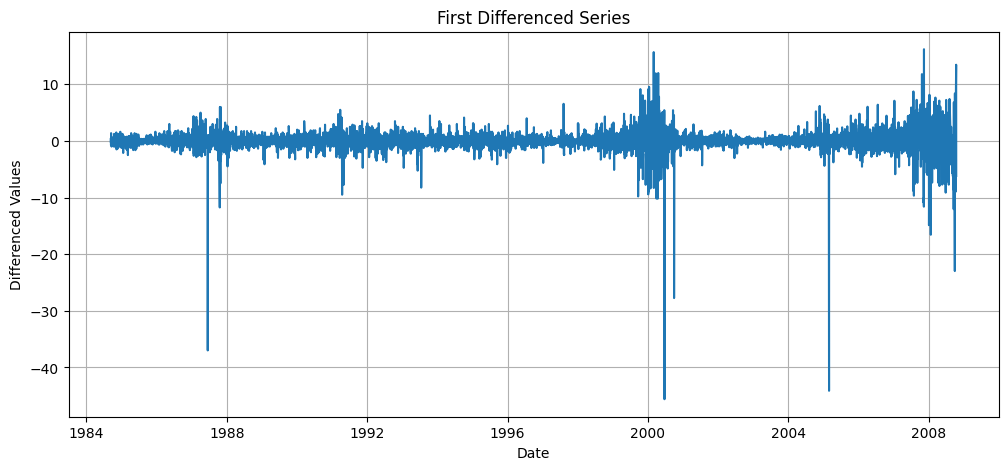

In [6]:
diff_1 = ts.diff().dropna()

plt.figure(figsize=(12,5))

plt.plot(diff_1)

plt.title("First Differenced Series")

plt.xlabel("Date")

plt.ylabel("Differenced Values")

plt.grid(True)

plt.show()

- Differencing removes trend and stabilizes the mean of the series.

### **ADF Test After Differencing**

In [7]:
adf_test(diff_1, "Differenced Series")

ADF Test for Differenced Series
ADF Statistic: -11.74269518687308
p-value: 1.2626020581628838e-21

Critical Values:
1% : -3.4314322297790083
5% : -2.862018246734374
10% : -2.567024568185534

Conclusion: Series is Stationary


- After differencing, the series becomes more stable and suitable for ARIMA modeling.

## **Plot ACF and PACF**

<Figure size 1200x500 with 0 Axes>

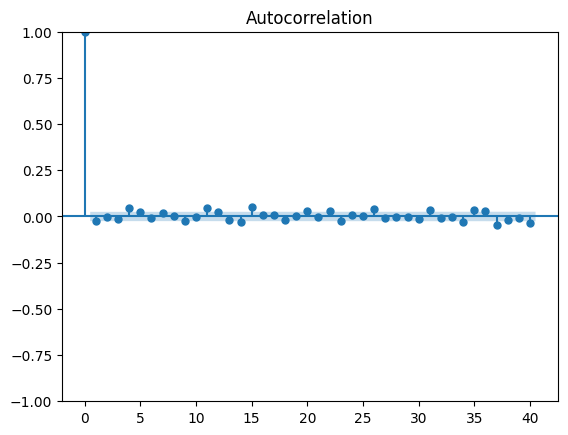

<Figure size 1200x500 with 0 Axes>

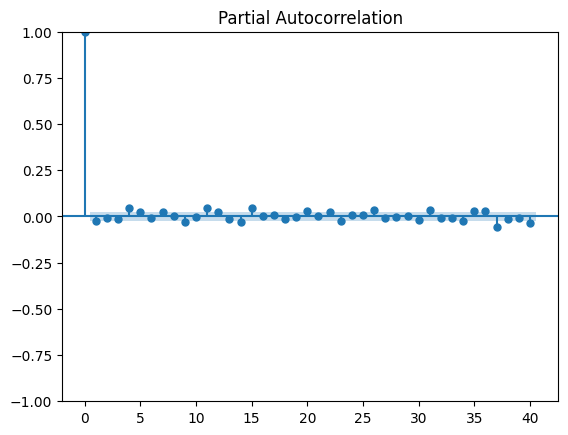

In [ ]:
plt.figure(figsize=(12,5))
plot_acf(diff_1, lags=40)
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(diff_1, lags=40)
plt.show()

- ACF and PACF plots help identify suitable ARIMA model parameters (p,d,q).

### **Train-Test Split**

In [9]:
train_size = int(len(ts) * 0.80)
train = ts[:train_size]
test = ts[train_size:]

print("Training Data:", len(train))
print("Testing Data:", len(test))

Training Data: 4864
Testing Data: 1217


- The first 80% of data is used for model training and the remaining 20% for testing.

## **Build Candidate Models**

- **Model 1 — ARIMA(1,1,1)**

In [ ]:
model_1 = ARIMA(train, order=(1,1,1))
model_1_fit = model_1.fit()
print(model_1_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 4864
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -9422.634
Date:                Sat, 16 May 2026   AIC                          18851.267
Time:                        08:25:40   BIC                          18870.735
Sample:                             0   HQIC                         18858.100
                               - 4864                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0480      0.175     -0.274      0.784      -0.392       0.296
ma.L1          0.0066      0.175      0.038      0.970      -0.336       0.349
sigma2         2.8218      0.007    407.293      0.0

- **Model 2 — ARIMA(2,1,2)**

In [11]:
model_2 = ARIMA(train, order=(2,1,2))
model_2_fit = model_2.fit()
print(model_2_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 4864
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -9418.392
Date:                Sat, 16 May 2026   AIC                          18846.784
Time:                        08:26:17   BIC                          18879.231
Sample:                             0   HQIC                         18858.172
                               - 4864                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0034      0.225      0.015      0.988      -0.438       0.445
ar.L2          0.5518      0.108      5.126      0.000       0.341       0.763
ma.L1         -0.0515      0.225     -0.229      0.8

- **Model 3 — SARIMA(1,1,1)(1,1,1,12)**

In [12]:
model_3 = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

model_3_fit = model_3.fit()
print(model_3_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Close   No. Observations:                 4864
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -9434.601
Date:                            Sat, 16 May 2026   AIC                          18879.203
Time:                                    08:26:59   BIC                          18911.637
Sample:                                         0   HQIC                         18890.588
                                           - 4864                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3637      0.167      2.183      0.029       0.037       0.690
ma.L1         -0.4031      0.164   

- **Three forecasting models are estimated for comparison and validation.**

## **Compare AIC and BIC**

In [13]:
comparison = pd.DataFrame({

    'Model': ['ARIMA(1,1,1)', 'ARIMA(2,1,2)', 'SARIMA(1,1,1)(1,1,1,12)'],

    'AIC': [
        model_1_fit.aic,
        model_2_fit.aic,
        model_3_fit.aic
    ],

    'BIC': [
        model_1_fit.bic,
        model_2_fit.bic,
        model_3_fit.bic
    ]
})

comparison

,Model,AIC,BIC
0,"ARIMA(1,1,1)",18851.267145,18870.735378
1,"ARIMA(2,1,2)",18846.783841,18879.230895
2,"SARIMA(1,1,1)(1,1,1,12)",18879.202513,18911.637214


### **Forecast on Test Set**

In [ ]:
forecast_1 = model_1_fit.forecast(steps=len(test))
forecast_2 = model_2_fit.forecast(steps=len(test))
forecast_3 = model_3_fit.forecast(steps=len(test))

- Accuracy Evaluation

In [ ]:
# Evaluation Function

def evaluate_model(actual, predicted):

    actual = np.array(actual)
    predicted = np.array(predicted)

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    # Avoid division by zero
    mask = actual != 0

    # Mean Absolute Percentage Error
    mape = np.mean(
        np.abs((actual[mask] - predicted[mask]) / actual[mask])
    ) * 100

    return mae, rmse, mape


# Create Results Table
results = pd.DataFrame(
    columns=['Model', 'MAE', 'RMSE', 'MAPE']
)


# Store Results
results.loc[0] = [
    'ARIMA(1,1,1)',
    *evaluate_model(test, forecast_1)
]

results.loc[1] = [
    'ARIMA(2,1,2)',
    *evaluate_model(test, forecast_2)
]

results.loc[2] = [
    'SARIMA(1,1,1)(1,1,1,12)',
    *evaluate_model(test, forecast_3)
]


# Display Results
results

,Model,MAE,RMSE,MAPE
0,"ARIMA(1,1,1)",63.908602,80.863379,64.516913
1,"ARIMA(2,1,2)",63.911229,80.865483,64.521270
2,"SARIMA(1,1,1)(1,1,1,12)",64.825314,81.827410,65.662185


### **Residual Diagnostics**

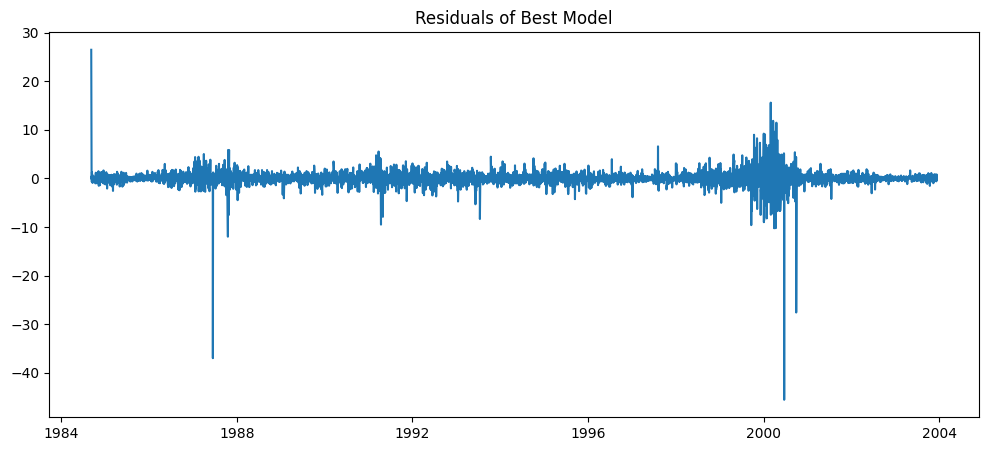

In [16]:
residuals = model_2_fit.resid

plt.figure(figsize=(12,5))

plt.plot(residuals)

plt.title("Residuals of Best Model")

plt.show()

### **Ljung-Box Test**

In [17]:
ljung_box = acorr_ljungbox(residuals, lags=[10], return_df=True)

ljung_box

,lb_stat,lb_pvalue
10,16.702856,0.081203


### **Select Best Model**

In [19]:
results

,Model,MAE,RMSE,MAPE
0,"ARIMA(1,1,1)",63.908602,80.863379,NaN
1,"ARIMA(2,1,2)",63.911229,80.865483,NaN
2,"SARIMA(1,1,1)(1,1,1,12)",64.825314,81.827410,NaN


### **Forecast Next 6 Periods**

In [20]:
future_forecast = model_2_fit.get_forecast(steps=6)

forecast_values = future_forecast.predicted_mean

confidence_intervals = future_forecast.conf_int()

print(forecast_values)

print(confidence_intervals)

4864    20.908907
4865    20.894609
4866    20.904993
4867    20.897139
4868    20.902843
4869    20.898528
Name: predicted_mean, dtype: float64
      lower Close  upper Close
4864    17.619455    24.198358
4865    16.353108    25.436110
4866    15.369177    26.440809
4867    14.563028    27.231250
4868    13.852215    27.953470
4869    13.216960    28.580096


### **Plot Forecasts**

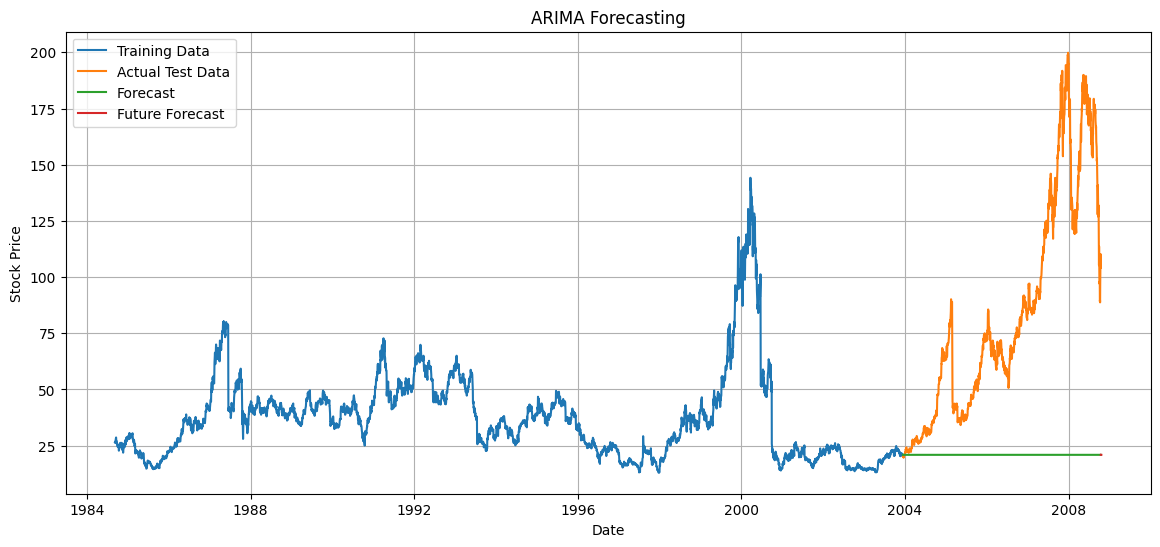

In [21]:
plt.figure(figsize=(14,6))

plt.plot(train.index, train, label='Training Data')

plt.plot(test.index, test, label='Actual Test Data')

plt.plot(test.index, forecast_2, label='Forecast')

future_index = pd.date_range(
    start=test.index[-1],
    periods=7,
    freq='D'
)[1:]

plt.plot(future_index, forecast_values, label='Future Forecast')

plt.legend()

plt.title("ARIMA Forecasting")

plt.xlabel("Date")

plt.ylabel("Stock Price")

plt.grid(True)

plt.show()

## Conclusion 

- Apple stock prices were analyzed using ARIMA and SARIMA forecasting models.
- Differencing was applied to stabilize the time series.
- Multiple models were compared using AIC, BIC, RMSE, MAE, and MAPE.
- The best forecasting model was selected based on model accuracy and residual diagnostics.
- Short-term forecasts suggest expected future movement in Apple stock prices.